<a href="https://colab.research.google.com/github/TKhahahah/Data_Mining_FinalProject/blob/main/LinearSVR_V23_11_TMD_ALLcluster_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.5 MB/s eta 0:00:00


## Library Version 22_4 : Dropout between later, Dense graphs, USe Otograohic precitaiton edges caled from U, W CW, Dem and leedside windside, AttentionLSTM_V8, No Quantile Mapping, adaptive_huber_loss with percentile_loss to handle Extreme Events. Input includes calculated indices: PDO, ONI, SWM, DMI, and downloaded indices: MEIV2, BSISO, and MJO. , NEW NE index


In [2]:
import os
import pandas as pd
import numpy as np
import sys
import datetime
import copy
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pickle
import random
import matplotlib.pyplot as plt
import copy
from dateutil.relativedelta import relativedelta
import time
import inspect
import time as countdown
from tqdm import tqdm
import time as countdown
from torch_geometric.data import HeteroData




import torch
import torch.nn as nn
from torch.nn.parameter import Parameter
import torch.nn.functional as F
from torch.nn import Parameter
from torch import Tensor


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')



In [3]:

import os, sys

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Hyperparameters

In [4]:
algo='LSTM_V23_11'

num_epoch = 300
window_size = 24  #Window size
horizon = 12   #Prediction horizon
TBPTT_K = 24

learn_rate =0.001
weight_decay =1e-4
cluster =9 #choose cluster of the HII stations
k_fold_num=2
percentile_loss =0.95

# PARAMETERS FOR SMALL DATA
noise_level = 0.05  # Standard deviation of noise (5% of signal)

min_epochs = 20
patience = 100
LOG_EVERY = 20


hidden_size_list =[128]
num_layers_list =[2]
drop_out_list=[0.4]



## Load dataset

In [5]:
X_index = pd.read_csv('/content/drive/MyDrive/KKU_Workshop3/X_variable(Index)_operation_v4.csv')
Y_rainfall = pd.read_csv('/content/drive/MyDrive/KKU_Workshop3/Y_variable(Rainfall).csv')
# Convert 'DATE' column in Y_df to datetime objects if it's not already
X_index['DATE'] = pd.to_datetime(X_index['DATE'])

# Format the dates in Y_df as 'YYYY-MM-01'
X_index['DATE'] = X_index['DATE'].dt.strftime('%Y-%m-01')



node = pd.read_csv('/content/drive/MyDrive/KKU_Workshop3/Node_table_TMD.csv')


path_feature = os.path.join("/content/drive/MyDrive/KKU_Workshop3/lookup_table_reanalysis_v5.csv")
feature = pd.read_csv(path_feature, header= "infer")



In [6]:
Y_rainfall = Y_rainfall.rename(columns={'code': 'Node'})

Y_rainfall_clean = Y_rainfall.copy()
num_feature = len(feature[feature['Cluster']==cluster])

In [7]:

def apply_time_lag(df, column_name, lag):
    # Create a new column name with the lag suffix
    new_column_name = f"{column_name}_lag{lag}"

    # Shift the column values by the specified lag
    df[new_column_name] = df[column_name].shift(lag)

    return df

# Define the time lags for each climate index

time_lags = {

    'MEIV2': [1, 2, 3],
    'RMM_AMPLITUDE': [1],
    'PHASE': [1],
    'PDO': [1, 2],
    'ONI': [1, 2],
    'DMI': [1, 2],
    'BSISO1': [1],
    'BSISO1-Phase': [1],
    'SWM': [1],

}




# Apply time lags to each specified column in df_merge_type
for column, lag in time_lags.items():
      if column in X_index.columns:
            for lag_item in lag:
                X_index = apply_time_lag(X_index, column, lag_item)
      else:
        print(f"Warning: Column '{column}' not found in df_merge_type. Skipping.")


Data cleansing

In [8]:
HQ_date_get_month_df  =  Y_rainfall.copy()
Y_rainfall_clean =  Y_rainfall.copy()
HQ_date_get_month_df['DATE'] = pd.to_datetime(Y_rainfall['DATE']).dt.month

month_avg_list = []
for month in range(1, 12 + 1):
    # Filter the data for the current year
    HQ_data = HQ_date_get_month_df[HQ_date_get_month_df['DATE'] == month]

    # Average rainfall
    av_r = HQ_data.iloc[:, 1:].median()

    # Create a dictionary to hold the data for this year
    month_dict = {'MONTH': month}
    month_dict.update(av_r)

    # Append the data for this year to the list
    month_avg_list.append(month_dict)

HQ_month_avg = pd.DataFrame(month_avg_list)

for i in range(1, len(Y_rainfall_clean.columns)):
    for j in range(0, len(Y_rainfall_clean)):
        if(np.isnan(Y_rainfall_clean.iloc[j, i])):
             Y_rainfall_clean.iloc[j, i] = HQ_month_avg.iloc[pd.to_datetime(Y_rainfall_clean.iloc[:, 0]).dt.month[j]-1, i]

In [9]:
Y_rainfall_clean['DATE'].max()

'2025-03-01'

In [10]:
start_training_date = '1982-01-01'


X_index['DATE'] = pd.to_datetime(X_index['DATE'])
Y_rainfall_clean['DATE'] = pd.to_datetime(Y_rainfall_clean['DATE'])
max_date_X = X_index['DATE'].max()
max_date_Y = Y_rainfall_clean['DATE'].max()
# Minimum date possible

print("Maximum date possible : ",start_training_date)


# Maximum date possible
max_date_possible = min([max_date_X,max_date_Y])
print("Maximum date possible : ",max_date_possible)

#Make condition
con_date_X = (X_index['DATE'] >= start_training_date) & (X_index['DATE'] <= max_date_possible)
con_date_Y = (Y_rainfall_clean['DATE'] >= start_training_date) & (Y_rainfall_clean['DATE'] <= max_date_possible)

#Final select
X_index_interval_date = X_index.loc[con_date_X,:]
Y_rainfall_clean = Y_rainfall_clean.loc[con_date_Y,:]


Y_rainfall_interval_date = copy.deepcopy(Y_rainfall_clean)

Maximum date possible :  1982-01-01
Maximum date possible :  2025-03-01 00:00:00


In [11]:
start_training_date = Y_rainfall_clean['DATE'].min()

X_index['DATE'] = pd.to_datetime(X_index['DATE'])
Y_rainfall_clean['DATE'] = pd.to_datetime(Y_rainfall_clean['DATE'])
max_date_X = X_index['DATE'].max()
max_date_Y = Y_rainfall_clean['DATE'].max()
# Minimum date possible

print("Maximum date possible : ",start_training_date)


# Maximum date possible
max_date_possible = min([max_date_X,max_date_Y])
print("Maximum date possible : ",max_date_possible)

#Make condition
con_date_X = (X_index['DATE'] >= start_training_date) & (X_index['DATE'] <= max_date_possible)
con_date_Y = (Y_rainfall_clean['DATE'] >= start_training_date) & (Y_rainfall_clean['DATE'] <= max_date_possible)

#Final select
X_index_interval_date = X_index.loc[con_date_X,:]
Y_rainfall_clean = Y_rainfall_clean.loc[con_date_Y,:]


Y_rainfall_interval_date = copy.deepcopy(Y_rainfall_clean)

Maximum date possible :  1982-01-01 00:00:00
Maximum date possible :  2025-03-01 00:00:00


In [12]:
#Count null value of each indexs
print("Number of index columns which contain null value : ",len(X_index_interval_date.isnull().sum()[X_index_interval_date.isnull().sum()>0]), sep="")
print("Number of rainfall station which contain null value : ",len(Y_rainfall_interval_date.isnull().sum()[Y_rainfall_interval_date.isnull().sum()>0]), sep="")

Number of index columns which contain null value : 0
Number of rainfall station which contain null value : 0


## Convert DATE columns to index columns

In [13]:
def convert_columns_to_index_columns(df,col_name):
    df.loc[:,col_name] = pd.to_datetime(df[col_name])
    df = df.set_index(col_name, inplace=False)
    return df

- independend variable dataframe

In [14]:
X_index_df_ready = convert_columns_to_index_columns(X_index_interval_date, 'DATE')
Y_rainfall_df_ready = convert_columns_to_index_columns(Y_rainfall_interval_date, 'DATE')

In [15]:
print("nrow of X : {}".format(X_index_df_ready.shape[0]))
print("nrow of Y : {}".format(X_index_df_ready.shape[0]))

nrow of X : 519
nrow of Y : 519


## Standardize

In [16]:

#scaler_X = MinMaxScaler()
scaler_X = StandardScaler()

X_normalize_data = scaler_X.fit_transform(X_index_df_ready)
X_index_normalized_df = pd.DataFrame(X_normalize_data, columns=X_index_df_ready.columns)

scaler_Y = StandardScaler()

Y_normalize_data = scaler_Y.fit_transform(Y_rainfall_df_ready)
Y_rainfall_normalized_df = pd.DataFrame(Y_normalize_data, columns=Y_rainfall_df_ready.columns)

In [17]:

# Save the scaler
with open('/content/drive/MyDrive/KKU_Workshop3/scaler_Y.pkl', 'wb') as file:
    pickle.dump(scaler_Y, file)
# Save the scaler
with open('/content/drive/MyDrive/KKU_Workshop3/scaler_X.pkl', 'wb') as file:
    pickle.dump(scaler_X, file)


# Load the scaler for inference
with open('/content/drive/MyDrive/KKU_Workshop3/scaler_Y.pkl', 'rb') as file:
    scaler_Y = pickle.load(file)

## Summarises all climate index

In [18]:
#Get date range from original files because after normalization index will reset
og_date_range = X_index_interval_date['DATE']
X_index_normalized_df.set_index(og_date_range, inplace=True)
Y_rainfall_normalized_df.set_index(og_date_range, inplace=True)

n_feature_climate = X_index_normalized_df.shape[1]
feature_climate = X_index_normalized_df.columns
print("Number of climate index feature : ",n_feature_climate)
print("All climate index : \n",feature_climate)

Number of climate index feature :  24
All climate index : 
 Index(['MEIV2', 'RMM_AMPLITUDE', 'PHASE', 'BSISO1', 'BSISO1-Phase', 'DMI',
       'ONI', 'PDO', 'SWM', 'NE', 'MEIV2_lag1', 'MEIV2_lag2', 'MEIV2_lag3',
       'RMM_AMPLITUDE_lag1', 'PHASE_lag1', 'PDO_lag1', 'PDO_lag2', 'ONI_lag1',
       'ONI_lag2', 'DMI_lag1', 'DMI_lag2', 'BSISO1_lag1', 'BSISO1-Phase_lag1',
       'SWM_lag1'],
      dtype='object')


## Add cos sin function to X

### Combine static feature

In [19]:
X_index_normalized_df['Month_sin'] = np.sin(2 * np.pi * X_index_normalized_df.index.month / 12)
X_index_normalized_df['Month_cos'] = np.cos(2 * np.pi * X_index_normalized_df.index.month / 12)

In [20]:
station_id_list = Y_rainfall_normalized_df.columns
list_table = []
for code_st in station_id_list:
  #print(code_st)

  #print(static_value)
  eindices_df = X_index_normalized_df.copy()



  eindices_df[code_st] = Y_rainfall_normalized_df[code_st]

  list_table.append(eindices_df)

In [21]:
n_feature_climate = X_index_normalized_df.shape[1]
feature_climate = X_index_normalized_df.columns
print("Number of climate index feature : ",n_feature_climate)
print("All climate index : \n",feature_climate)

Number of climate index feature :  26
All climate index : 
 Index(['MEIV2', 'RMM_AMPLITUDE', 'PHASE', 'BSISO1', 'BSISO1-Phase', 'DMI',
       'ONI', 'PDO', 'SWM', 'NE', 'MEIV2_lag1', 'MEIV2_lag2', 'MEIV2_lag3',
       'RMM_AMPLITUDE_lag1', 'PHASE_lag1', 'PDO_lag1', 'PDO_lag2', 'ONI_lag1',
       'ONI_lag2', 'DMI_lag1', 'DMI_lag2', 'BSISO1_lag1', 'BSISO1-Phase_lag1',
       'SWM_lag1', 'Month_sin', 'Month_cos'],
      dtype='object')


## Split dataframe to add static feature

### Import meta data

### Add new date and latitude-longitude format columns

## Split training and testing

### Define start and end date of each interval

# Train Fold 1 = 2018-2020, Val = 2018-2020, Test = 2019 - 2021

# Train Fold 2 = 2018-2022, Val = 2021-2023, Test = 1/2022 - 12/2024

In [22]:
#Train interval

start_interval_train1 =  pd.to_datetime(min(Y_rainfall_normalized_df.index))
#maximum_interval_train = max(Y_rainfall_normalized_df.index[0:-6])


end_interval_train1 = start_interval_train1 + relativedelta(months=37*12+11)


#Test1 interval
start_interval_val1 = start_interval_train1 + relativedelta(months=36*12)
end_interval_val1 =  start_interval_train1 + relativedelta(months=38*12+11)



#Test1 interval
start_interval_test1 = start_interval_train1 + relativedelta(months=37*12)
end_interval_test1 = start_interval_train1 + relativedelta(months=39*12+11)
#end_interval_test = start_interval_test + relativedelta(months=backward_months+17)
#Display
print("############################################################")
print("TRAINING Fold 1")
print('Start interval date of training set: ', start_interval_train1)
#print('Maximum interval date : ', maximum_interval_train)
print('End interval date of training set :', end_interval_train1)

print("############################################################")
print("VALIDATION Fold 1")
print('Start interval date of testing set: ', start_interval_val1)
print('End interval date of testing set :', end_interval_val1)
print("############################################################")



print("############################################################")
print("TESTING Fold 1")
print('Start interval date of testing set: ', start_interval_test1)
print('End interval date of testing set :', end_interval_test1)
print("############################################################")
#if cluster in [4 ,5,6,7, 8,9 ,10,11,12]:
#    start_interval_train1 = start_interval_val1 +  relativedelta(months=1)

#    end_interval_train2 = start_interval_train1 +  relativedelta(months=4*12+12)


    #Train interval
#    start_interval_val2 = start_interval_train1 +  relativedelta(months=3*12-1)
#    end_interval_val2 = start_interval_train1 +  relativedelta(months=5*12+10)



    #Test2 interval
#    start_interval_test2 = start_interval_train1 +  relativedelta(months=3*12+9)
#    end_interval_test2 = start_interval_train1 +  relativedelta(months=6*12+11-3)

#else:
start_interval_train1 = start_interval_train1

end_interval_train2 = start_interval_train1 + relativedelta(months=40*12)


    #Train interval
start_interval_val2 = start_interval_train1  + relativedelta(months=39*12)
end_interval_val2 = start_interval_train1 + relativedelta(months=41*12+11)



    #Test2 interval
start_interval_test2 = start_interval_train1 + relativedelta(months=40*12)
end_interval_test2 = start_interval_train1 + relativedelta(months=42*12+11)


#Display
print("############################################################")
print("TRAINING Fold 2")
print('Start interval date of training set: ', start_interval_train1)
#print('Maximum interval date : ', maximum_interval_train)
print('End interval date of training set :', end_interval_train2)

print("############################################################")
print("VALIDATION Fold 2")
print('Start interval date of testing set: ', start_interval_val2)
print('End interval date of testing set :', end_interval_val2)
print("############################################################")



print("############################################################")
print("TESTING Fold 2")
print('Start interval date of testing set: ', start_interval_test2)
print('End interval date of testing set :', end_interval_test2)
print("############################################################")

# Train Fold 1 = 1982-2019, Val = 2018-2020, Test = 2019 - 2021

# Train Fold 2 = 1982-2022, Val = 2021-2023, Test = 2022 - 2024

############################################################
TRAINING Fold 1
Start interval date of training set:  1982-01-01 00:00:00
End interval date of training set : 2019-12-01 00:00:00
############################################################
VALIDATION Fold 1
Start interval date of testing set:  2018-01-01 00:00:00
End interval date of testing set : 2020-12-01 00:00:00
############################################################
############################################################
TESTING Fold 1
Start interval date of testing set:  2019-01-01 00:00:00
End interval date of testing set : 2021-12-01 00:00:00
############################################################
############################################################
TRAINING Fold 2
Start interval date of training set:  1982-01-01 00:00:00
End interval date of training set : 2022-01-01 00:00:00
############################################################
VALIDATION Fold 2
Start interval date of testing set:  2

### Split training and testing

In [23]:
#Split test and train

Train_df_list1, Val_df_list1, Test_df_list1,Train_df_list2,  Val_df_list2 ,Test_df_list2 = [], [],[],[],[],[]
for i_table in range(len(list_table)):
  Train_df_list1.append(list_table[i_table][start_interval_train1:end_interval_train1])
  Val_df_list1.append(list_table[i_table][start_interval_val1:end_interval_val1])
  Test_df_list1.append(list_table[i_table][start_interval_test1:end_interval_test1])
  Train_df_list2.append(list_table[i_table][start_interval_train1:end_interval_train2])
  Val_df_list2.append(list_table[i_table][start_interval_val2:end_interval_val2])
  Test_df_list2.append(list_table[i_table][start_interval_test2:end_interval_test2])

fold =[]
fold.append([Train_df_list1,Test_df_list1,Val_df_list1])
fold.append([Train_df_list2,Test_df_list2,Val_df_list2])


# Feature selection part

## Focus only feature of climate

In [24]:
print("The first feature size that is climate index:", n_feature_climate)

The first feature size that is climate index: 26


In [25]:
selected_index =[]
feature_cluster =  feature[feature['Cluster']==cluster]
for feature_index in range(len(feature_cluster)):
    for i in range(len(feature_climate)):
        if((feature_climate[i] == feature_cluster.iloc[feature_index,1]) and feature_cluster.iloc[feature_index,5] == 0):
                selected_index.append(i)

        elif(feature_cluster.iloc[feature_index,5] != 0):
            for i_lag in range(len(feature_climate)):
                if(feature_climate[i_lag] == feature_cluster.iloc[feature_index,1]+'_lag'+str(feature_cluster.iloc[feature_index,5])):
                    selected_index.append(i_lag)
                    break
                else:
                    continue  # Continue if the inner loop wasn't broken.
            break  # Inner loop was broken, break the outer.

selected_index.sort()
feature_climate[selected_index]


Index(['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'ONI', 'SWM', 'NE', 'Month_sin',
       'Month_cos'],
      dtype='object')

## Feature selection
- Create binary position (length = climate feature)

In [26]:
random.seed(10)
position_optimal = [0 for i in range(n_feature_climate)]
#position_remain = (Train_df_list[0].shape[1] - n_feature_climate)*[1]
position_remain = [0, 0, 1] # select rain

for id in selected_index:
  position_optimal[id]=1

position_all = position_optimal + position_remain
position_all_index = [index for index,value in enumerate(position_all) if value == 1]
climate_name_list = [feature_climate[index] for index,value in enumerate(position_optimal) if value == 1]

print("position_all_index : ", position_all_index)
print("Climate index : ", climate_name_list)

position_all_index :  [1, 3, 5, 6, 8, 9, 24, 25, 28]
Climate index :  ['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'ONI', 'SWM', 'NE', 'Month_sin', 'Month_cos']


## Select columns by position vector (position_all)

In [27]:
random.seed(10)
position_optimal = [0 for i in range(n_feature_climate)]
#position_remain = (Train_df_list[0].shape[1] - n_feature_climate)*[1]
position_remain = [1] # select rain

for id in selected_index:
  position_optimal[id]=1

position_all = position_optimal + position_remain
position_all_index = [index for index,value in enumerate(position_all) if value == 1]
climate_name_list = [feature_climate[index] for index,value in enumerate(position_optimal) if value == 1]

print("position_all_index : ", position_all_index)
print("Climate index : ", climate_name_list)

position_all_index :  [1, 3, 5, 6, 8, 9, 24, 25, 26]
Climate index :  ['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'ONI', 'SWM', 'NE', 'Month_sin', 'Month_cos']


In [28]:
def select_feature_f(list_df,position_feature_index):
    for i in range(len(list_df)):
        list_df[i] = list_df[i].iloc[:,position_feature_index]
    return list_df

In [29]:
#Fold 1 = Fold[0] , Fold 2 = Fold[1]
#Test Fold 1 = Fold[0][0] , Train Fold 1 = Fold[0][1], Validation Fold 1 = Fold[0][2]
fold[0][0] = select_feature_f(list_df = fold[0][0], position_feature_index = position_all_index)
fold[0][1] = select_feature_f(list_df = fold[0][1], position_feature_index = position_all_index)
fold[0][2] = select_feature_f(list_df = fold[0][2], position_feature_index = position_all_index)
fold[1][0] = select_feature_f(list_df = fold[1][0], position_feature_index = position_all_index)
fold[1][1] = select_feature_f(list_df = fold[1][1], position_feature_index = position_all_index)
fold[1][2] = select_feature_f(list_df = fold[1][2], position_feature_index = position_all_index)

In [30]:
len(Y_rainfall_normalized_df.columns)

132

## Read node location

In [31]:
cluster_station= []
for index in range(0,len(Y_rainfall_normalized_df.columns)):
    if (node['quality'].iloc[index]==1 and node['cluster'].iloc[index]==cluster) :
            cluster_station.append(index)


In [32]:
for index in range(len(cluster_station)):
    print(node['Node'].iloc[cluster_station[index]])

400201
402301
425201
425301
426201
430201
440201
450201
451301
455201
455301
455601
459201
459202
478301
500202
500301


Create node

Creat training test set for each station

Create static features

In [33]:
num_feature = len(feature[feature['Cluster']==cluster])

## Check edges

In [34]:

def extract_features(feature,j, window_size,horizon,data_list):
    xs_list= []
    for station in cluster_station:
        xs_new= np.array(data_list[station].iloc[:,feature][j:j+window_size])
        xs_list.append([xs_new])
    xs = np.array(xs_list)
    return xs

In [35]:
climate_name_list

['RMM_AMPLITUDE',
 'BSISO1',
 'DMI',
 'ONI',
 'SWM',
 'NE',
 'Month_sin',
 'Month_cos']

Add snapshot signal in = Windows , out = 12

Train_df_listCreate edges

In [36]:
num_feature

8

Convert to homogenious structure

In [37]:


# Station id
s=0



#Sliding window Train
fold_tensor = copy.deepcopy(fold)

for fold_index in range(k_fold_num):
    train_set =[]
    train= HeteroData()

    test_set =[]
    test= HeteroData()

    val_set =[]
    val = HeteroData()


    for j in range(len(fold[fold_index][0][s]) - window_size - horizon + 1):
        # if j%(window_size-1)==0: #
        #if j%3==0: #
        tan_x=[]
        rain_fall_x=[]
        rain_fall_y=[]

        for station in cluster_station:
            tan_x.append([(fold[fold_index][0][station][fold[fold_index][0][station].columns[-2]][j:j+window_size])])
            rain_fall_x.append([(fold[fold_index][0][station][fold[fold_index][0][station].columns[-1]][j:j+window_size])])
            rain_fall_y.append([(fold[fold_index][0][station][fold[fold_index][0][station].columns[-1]][j+window_size:j+window_size+horizon])])


        for climate_index in range(len(climate_name_list)):

            train[climate_name_list[climate_index]].x = torch.tensor(extract_features(climate_index,j, window_size,horizon,fold[fold_index][0]), dtype=torch.float32)
        train['station'].x = torch.tensor(np.array(rain_fall_x), dtype=torch.float32)
        train['station'].y = torch.tensor(np.array(rain_fall_y), dtype=torch.float32)

        train_set.append(copy.deepcopy(train))

    fold_tensor[fold_index][0] = train_set
    #Sliding window Test

    for j in range(len(fold[fold_index][1][s]) - window_size - horizon + 1):
        tan_x =[]
        rain_fall_x=[]
        rain_fall_y=[]
        for station in cluster_station:
            tan_x.append([(fold[fold_index][1][station][fold[fold_index][1][station].columns[-2]][j:j+window_size])])
            rain_fall_x.append([(fold[fold_index][1][station][fold[fold_index][1][station].columns[-1]][j:j+window_size])])
            rain_fall_y.append([(fold[fold_index][1][station][fold[fold_index][1][station].columns[-1]][j+window_size:j+window_size+horizon])])


        for climate_index in range(len(climate_name_list)):

            test[climate_name_list[climate_index]].x = torch.tensor(extract_features(climate_index,j, window_size,horizon,fold[fold_index][1]), dtype=torch.float32)


        test['station'].x = torch.tensor(np.array(rain_fall_x), dtype=torch.float32)
        test['station'].y = torch.tensor(np.array(rain_fall_y), dtype=torch.float32)


        test_set.append(copy.deepcopy(test))

    fold_tensor[fold_index][1] = test_set


    for j in range(len(fold[fold_index][2][s]) - window_size - horizon + 1):
        tan_x =[]
        rain_fall_x=[]
        rain_fall_y=[]
        for station in cluster_station:
            tan_x.append([(fold[fold_index][2][station][fold[fold_index][2][station].columns[-2]][j:j+window_size])])
            rain_fall_x.append([(fold[fold_index][2][station][fold[fold_index][2][station].columns[-1]][j:j+window_size])])
            rain_fall_y.append([(fold[fold_index][2][station][fold[fold_index][2][station].columns[-1]][j+window_size:j+window_size+horizon])])

        for climate_index in range(len(climate_name_list)):
            val[climate_name_list[climate_index]].x = torch.tensor(extract_features(climate_index,j, window_size,horizon,fold[fold_index][2]), dtype=torch.float32)

        val['station'].x = torch.tensor(np.array(rain_fall_x), dtype=torch.float32)
        val['station'].y = torch.tensor(np.array(rain_fall_y), dtype=torch.float32)



        val_set.append(copy.deepcopy(val))

    fold_tensor[fold_index][2] = val_set



In [38]:
def extract_x(data):
    datax =[]
    i=0
    cluster_i=0
    for feature_index in range((num_feature)):

        datax.append([data.x[i][0].detach().cpu().numpy()])
        i=i+len(cluster_station)
    #result = torch.cat(datax, dim=1)
    for cluster_index in range(len(cluster_station)):

        datax.append([data.x[i+cluster_i][0].detach().cpu().numpy()])
        cluster_i=cluster_i+1
    return datax


In [39]:

def accuracy2D_classic(y_pred, y_target):
    y_pred=y_pred.detach().cpu().numpy()
    y_target=y_target.detach().cpu().numpy()
    y_pred =np.reshape(y_pred,y_pred.shape[0]*y_pred.shape[1])
    y_target =np.reshape(y_target,y_target.shape[0]*y_target.shape[1])
    a = [1-min(1,abs((j-i)/i)) for j,i in zip(y_pred, y_target) if i !=0]
    for i in range(len(y_target)):
        if y_target[i]==0:
            a[i] = 1-min(1,2*abs(y_pred[i]-y_target[i])/abs(y_pred[i]+y_target[i]))

    return np.array(a)

In [40]:
def transformback_future(pred,station,n):

    preds_temp = np.ones(Y_normalize_data.shape)
    for i in range(len(pred)):
        preds_temp[Y_normalize_data.shape[0]-n+i,station] =pred[pred.shape[0]-n+i]
    preds_values = scaler_Y.inverse_transform(preds_temp)
    preds_value = preds_values[preds_values.shape[0]-n:preds_values.shape[0],station]
    return (preds_value)

In [41]:
import torch
from typing import Dict, Union, List

def nse_per_station(observations, predictions, station_indices=None):
    """
    Compute the Nash-Sutcliffe Efficiency (NSE) for each station separately.

    Args:
        observations (torch.Tensor): Ground truth values, shape (num_stations, num_timesteps).
        predictions (torch.Tensor): Predicted values, same shape as `observations`.
        station_indices (Dict[str, int], optional): Dictionary mapping station names to their
                                                  indices in the tensors.

    Returns:
        Dict[str, float]: Nash-Sutcliffe Efficiency (NSE) score for each station.
    """
    # Ensure inputs have the correct shape
    if observations.dim() != 2 or predictions.dim() != 2:
        raise ValueError("Inputs must be 2D tensors with shape (num_stations, num_timesteps)")

    if observations.shape != predictions.shape:
        raise ValueError(f"Shape mismatch: observations {observations.shape}, predictions {predictions.shape}")

    num_stations = observations.shape[0]

    # Initialize results dictionary
    if station_indices is None:
        # If no station names provided, use numerical indices
        station_indices = {str(i): i for i in range(num_stations)}

    nse_scores = {}

    # Calculate NSE for each station
    for station_name, idx in station_indices.items():
        # Get data for this station
        station_obs = observations[idx]
        station_pred = predictions[idx]

        # Skip stations with NaN values if needed
        if torch.isnan(station_obs).any() or torch.isnan(station_pred).any():
            # Handle NaN values by filtering them out
            valid_mask = ~(torch.isnan(station_obs) | torch.isnan(station_pred))
            station_obs = station_obs[valid_mask]
            station_pred = station_pred[valid_mask]

            # Skip if no valid data points remain
            if len(station_obs) == 0:
                nse_scores[station_name] = float('nan')
                continue

        # Calculate mean of observations for THIS STATION only
        mean_obs = torch.mean(station_obs)

        # Compute numerator (sum of squared residuals)
        numerator = torch.sum((station_obs - station_pred) ** 2)

        # Compute denominator (sum of squared deviations from mean of observations)
        denominator = torch.sum((station_obs - mean_obs) ** 2)

        # Avoid division by zero
        if denominator == 0:
            # If predictions match observations exactly when they're all the same value
            if numerator == 0:
                nse_scores[station_name] = 1.0
            else:
                nse_scores[station_name] = float('nan')  # NSE undefined
        else:
            # Compute NSE for this station
            station_nse = 1 - (numerator / denominator)
            nse_scores[station_name] = station_nse.item()

    return nse_scores



In [42]:
def adaptive_huber_loss(y_pred, y_true, delta=1.0):
    """
    Huber loss with adaptive delta parameter based on data distribution

    Args:
        y_pred: Model predictions
        y_true: Ground truth values
        delta: Threshold parameter that determines quadratic vs. linear loss regions
    """
    # Calculate absolute error
    abs_error = torch.abs(y_pred - y_true)

    # Adapt delta based on data distribution (e.g., use 90th percentile)
    if delta is None:
        delta = torch.quantile(abs_error.detach(), 0.9)

    # Apply Huber loss formula
    quadratic_mask = (abs_error <= delta)
    linear_mask = ~quadratic_mask

    quadratic_loss = 0.5 * (abs_error ** 2)
    linear_loss = delta * (abs_error - 0.5 * delta)

    return torch.mean(quadratic_mask * quadratic_loss + linear_mask * linear_loss)

In [43]:
def nse(observations, predictions):
    """
    Compute the Nash-Sutcliffe Efficiency (NSE) between observed and predicted values.

    Args:
        observations (torch.Tensor): Ground truth values, shape (batch_size, ...).
        predictions (torch.Tensor): Predicted values, same shape as `observations`.

    Returns:
        float: Nash-Sutcliffe Efficiency (NSE) score.
    """


    # Calculate the mean of observed values
    mean_obs = np.mean(observations)

    # Compute numerator (sum of squared residuals)
    numerator = np.sum((observations - predictions) ** 2)

    # Compute denominator (sum of squared deviations from mean of observations)
    denominator = np.sum((observations - mean_obs) ** 2)

    # Avoid division by zero
    if denominator == 0:
        return float('nan')  # NSE cannot be computed if observations have zero variance

    # Compute and return NSE
    nse_score = 1 - (numerator / denominator)
    return nse_score.item()  # Convert to Python float for readability


In [44]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def inverse_transform_station_with_nans(scaled_predictions, station_index, scaler_object):
    """
    Efficiently transforms scaled predictions for a single station that may contain NaN
    values, using a multi-feature scaler. NaNs in the input are preserved as NaNs
    in the output.

    Args:
        scaled_predictions (np.ndarray):
            A 1D NumPy array containing the scaled predictions (and potentially NaNs)
            for a single station.

        station_index (int):
            The column index of the station that these predictions belong to.

        scaler_object (object):
            The multi-feature scikit-learn scaler object (e.g., MinMaxScaler) that
            was fitted on the complete, original dataset.

    Returns:
        np.ndarray:
            A 1D NumPy array of the same size as the input, with predictions in their
            original scale and NaNs preserved in their original positions.
    """
    # --- 1. Identify the locations of valid data and NaNs ---
    # Create a boolean mask to find where the valid numbers are.
    valid_mask = ~np.isnan(scaled_predictions)

    # Extract only the valid, non-NaN scaled prediction values.
    valid_scaled_preds = scaled_predictions[valid_mask]

    # If there are no valid values to transform, return the original array.
    if valid_scaled_preds.size == 0:
        return scaled_predictions

    # --- 2. Use the dummy array trick ONLY for the valid data ---
    # Get the total number of features (stations) the scaler was trained on.
    n_features = scaler_object.n_features_in_

    # Create a small dummy array. Its height is the number of *valid* predictions.
    # Its width is the total number of features.
    dummy_array = np.zeros((len(valid_scaled_preds), n_features))

    # Inject the valid predictions into the correct station's column.
    dummy_array[:, station_index] = valid_scaled_preds

    # --- 3. Perform the inverse transformation ---
    # This is efficient as it only transforms the valid data points.
    unscaled_dummy_array = scaler_object.inverse_transform(dummy_array)

    # Extract the now unscaled *valid* predictions from the correct column.
    unscaled_valid_preds = unscaled_dummy_array[:, station_index]

    # --- 4. Re-insert the transformed values back into a full-sized array ---
    # Create a new array of the original size, filled with NaNs.
    final_predictions = np.full_like(scaled_predictions, np.nan, dtype=float)

    # Use the boolean mask from step 1 to place the unscaled valid values
    # back into their original positions.
    final_predictions[valid_mask] = unscaled_valid_preds

    return final_predictions

In [45]:
def quantile_mapper(value, historical_preds, historical_obs):
        """
        Maps a value from the prediction distribution to the observation distribution.

        Args:
            value (float): The predicted value to be corrected (in mm).
            historical_preds (np.array): Sorted array of historical predictions.
            historical_obs (np.array): Sorted array of historical observations.

        Returns:
            float: The corrected value in mm.
        """
        # Find the percentile of the predicted value
        percentile = percentileofscore(historical_preds, value)

        # Find the corresponding value at that percentile in observations
        corrected_value = np.percentile(historical_obs, percentile, method='closest_observation')

        return corrected_value

In [46]:
len(cluster_station)

17

#Model LinearSVR

In [87]:
# ============================================================
# LinearSVR — Fold 1 & Fold 2
# ============================================================
import numpy as np
import pandas as pd
from sklearn.svm import LinearSVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Hyperparameters (เปลี่ยนได้) ─────────────────────────────
WINDOW   = 24   # เดือนที่ใช้เป็น input  (เหมือน LSTM)
HORIZON  = 12   # เดือนที่ทำนายล่วงหน้า (เหมือน LSTM)
C_VALUE  = 1.0  # regularization ของ SVR
MAX_ITER = 5000

# ── Fold config ───────────────────────────────────────────────
folds = {
    1: {
        'train_start': '1982-01-01',
        'train_end': '2019-12-31',
        'val_start': '2018-01-01',
        'val_end': '2020-12-31',
        'test_start': '2019-01-01',
        'test_end': '2021-12-31',
        'pred_year': 2022
    },
    2: {
        'train_start': '1982-01-01',
        'train_end': '2022-12-31',
        'val_start': '2021-01-01',
        'val_end': '2023-12-31',
        'test_start': '2022-01-01',
        'test_end': '2024-12-31',
        'pred_year': 2025
    }
}

In [88]:
# ============================================================
# ฟังก์ชันสร้าง sliding-window samples
# X_all : DataFrame คอลัมน์ = features + rainfall (ทุก station)
# y_all : DataFrame คอลัมน์ = rainfall ของ station ที่สนใจ
# ============================================================
def make_samples(X_all: pd.DataFrame,
                 y_all: pd.DataFrame,
                 window: int = WINDOW,
                 horizon: int = HORIZON):
    """
    คืนค่า:
      X_out : (N, window * n_features)  ← flatten แล้ว
      y_out : (N, horizon)
      dates : รายการวันที่ของ timestamp แรกใน horizon
    """
    X_vals = X_all.values
    y_vals = y_all.values
    n = len(X_vals)

    X_list, y_list, date_list = [], [], []
    dates_idx = X_all.index

    for i in range(n - window - horizon + 1):
        x_win  = X_vals[i : i + window]          # (window, n_feat)
        y_hor  = y_vals[i + window : i + window + horizon]  # (horizon, n_station)

        X_list.append(x_win.flatten())            # → 1D vector
        y_list.append(y_hor)
        date_list.append(dates_idx[i + window])   # วันแรกของ horizon

    return (np.array(X_list),   # (N, window*n_feat)
            np.array(y_list),   # (N, horizon, n_station)  หรือ (N, horizon) ถ้า 1 station
            date_list)

In [89]:
# ============================================================
# ฟังก์ชันคำนวณ NSE และ Accuracy (เหมือน LSTM notebook)
# ============================================================
def nse(obs, pred):
    """Nash-Sutcliffe Efficiency"""
    return 1 - np.sum((obs - pred)**2) / np.sum((obs - np.mean(obs))**2)

def accuracy_score_2d(obs, pred, threshold=0.1):
    """Accuracy แบบ direction / within-threshold"""
    return np.mean(np.abs(obs - pred) <= (np.abs(obs) * threshold + 1e-6))

def compute_metrics(obs, pred, label=""):
    mae  = mean_absolute_error(obs.flatten(), pred.flatten())
    rmse = np.sqrt(mean_squared_error(obs.flatten(), pred.flatten()))
    r2   = r2_score(obs.flatten(), pred.flatten())
    nse_ = nse(obs.flatten(), pred.flatten())
    print(f"[{label}]  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}  NSE={nse_:.4f}")
    return dict(mae=mae, rmse=rmse, r2=r2, nse=nse_)

In [90]:
# ============================================================
# เตรียมข้อมูล — ปรับ X_full, Y_full ให้ตรงกับ notebook ของคุณ
# ============================================================
# *** ตรงนี้ให้แทน X_index และ Y_rainfall ของคุณเองครับ ***

# X_full = X_index.set_index('DATE')  ← features ทุก column
# Y_full = Y_rainfall.set_index('DATE')[['station_1', ...]]

# ตัวอย่างสมมติ (ถ้ายังไม่มีข้อมูล):
# X_full = pd.DataFrame(...)
# Y_full = pd.DataFrame(...)

# ให้ index เป็น DatetimeIndex
X_index.index = pd.to_datetime(X_index.index)
Y_rainfall.index = pd.to_datetime(Y_rainfall.index)

# Drop the 'DATE' column as it's now in the index and not needed for scaling
X_index = X_index.drop(columns=['DATE'], errors='ignore')
Y_rainfall = Y_rainfall.drop(columns=['DATE'], errors='ignore')

In [93]:
# ── ตรวจ index ก่อนเลย ──────────────────────────────────────
print("X_index index type :", type(X_index.index))
print("X_index index sample:", X_index.index[:5].tolist())
print("X_index shape       :", X_index.shape)
print()
print("Y_rainfall index sample:", Y_rainfall.index[:5].tolist())
print("Y_rainfall shape        :", Y_rainfall.shape)
print()
print("Date range:", X_index.index.min(), "→", X_index.index.max())

X_index index type : <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
X_index index sample: [Timestamp('1970-01-01 00:00:00'), Timestamp('1970-01-01 00:00:00.000000001'), Timestamp('1970-01-01 00:00:00.000000002'), Timestamp('1970-01-01 00:00:00.000000003'), Timestamp('1970-01-01 00:00:00.000000004')]
X_index shape       : (541, 24)

Y_rainfall index sample: [Timestamp('1970-01-01 00:00:00'), Timestamp('1970-01-01 00:00:00.000000001'), Timestamp('1970-01-01 00:00:00.000000002'), Timestamp('1970-01-01 00:00:00.000000003'), Timestamp('1970-01-01 00:00:00.000000004')]
Y_rainfall shape        : (771, 132)

Date range: 1970-01-01 00:00:00 → 1970-01-01 00:00:00.000000540


In [94]:
# ── ตรวจว่า DATE column อยู่ที่ไหน ──────────────────────────
print("X_index columns:", X_index.columns.tolist()[:10])
print()
print("Y_rainfall columns:", Y_rainfall.columns.tolist()[:10])

X_index columns: ['MEIV2', 'RMM_AMPLITUDE', 'PHASE', 'BSISO1', 'BSISO1-Phase', 'DMI', 'ONI', 'PDO', 'SWM', 'NE']

Y_rainfall columns: ['300201', '300202', '303201', '303301', '310201', '327202', '327301', '327501', '328201', '328202']


In [95]:
# ── โหลดใหม่ตั้งแต่ต้น แก้ให้ถูกต้อง ────────────────────────
X_index    = pd.read_csv('/content/drive/MyDrive/KKU_Workshop3/X_variable(Index)_operation_v4.csv')
Y_rainfall = pd.read_csv('/content/drive/MyDrive/KKU_Workshop3/Y_variable(Rainfall).csv')

# ตรวจ column DATE ก่อน set_index
print("X_index columns (raw)    :", X_index.columns.tolist()[:5])
print("X_index DATE sample      :", X_index['DATE'].head(5).tolist())
print()
print("Y_rainfall columns (raw) :", Y_rainfall.columns.tolist()[:5])
print("Y_rainfall DATE sample   :", Y_rainfall['DATE'].head(5).tolist())

X_index columns (raw)    : ['DATE', 'MEIV2', 'RMM_AMPLITUDE', 'PHASE', 'BSISO1']
X_index DATE sample      : ['1/1/1981', '2/1/1981', '3/1/1981', '4/1/1981', '5/1/1981']

Y_rainfall columns (raw) : ['DATE', '300201', '300202', '303201', '303301']
Y_rainfall DATE sample   : ['1961-01-01', '1961-02-01', '1961-03-01', '1961-04-01', '1961-05-01']


In [98]:
# ── โหลดใหม่ถูกต้อง ──────────────────────────────────────────
X_index    = pd.read_csv('/content/drive/MyDrive/KKU_Workshop3/X_variable(Index)_operation_v4.csv')
Y_rainfall = pd.read_csv('/content/drive/MyDrive/KKU_Workshop3/Y_variable(Rainfall).csv')

# ตรวจก่อนว่า DATE column อยู่ที่ไหน และหน้าตาเป็นยังไง
print(X_index.columns.tolist()[:6])
print(X_index['DATE'].head(5).tolist())
print()
print(Y_rainfall.columns.tolist()[:6])
print(Y_rainfall['DATE'].head(5).tolist())

['DATE', 'MEIV2', 'RMM_AMPLITUDE', 'PHASE', 'BSISO1', 'BSISO1-Phase']
['1/1/1981', '2/1/1981', '3/1/1981', '4/1/1981', '5/1/1981']

['DATE', '300201', '300202', '303201', '303301', '310201']
['1961-01-01', '1961-02-01', '1961-03-01', '1961-04-01', '1961-05-01']


In [103]:
# ── โหลดและแปลง DATE ให้ถูกต้อง ─────────────────────────────
X_index    = pd.read_csv('/content/drive/MyDrive/KKU_Workshop3/X_variable(Index)_operation_v4.csv')
Y_rainfall = pd.read_csv('/content/drive/MyDrive/KKU_Workshop3/Y_variable(Rainfall).csv')

# X_index: format M/D/YYYY เช่น '1/1/1981' = Jan 1981
X_index['DATE'] = pd.to_datetime(X_index['DATE'], format='%m/%d/%Y')
X_index = X_index.set_index('DATE')

# Y_rainfall: format YYYY-MM-DD ปกติ
Y_rainfall['DATE'] = pd.to_datetime(Y_rainfall['DATE'])
Y_rainfall = Y_rainfall.set_index('DATE')

# ── ตัดให้ index ตรงกัน (เอาช่วงที่ทั้งคู่มีข้อมูล) ──────────
common_start = max(X_index.index.min(), Y_rainfall.index.min())
common_end   = min(X_index.index.max(), Y_rainfall.index.max())

X_index    = X_index.loc[common_start : common_end]
Y_rainfall = Y_rainfall.loc[common_start : common_end]

# ── ตรวจผล ───────────────────────────────────────────────────
print("X_index  :", X_index.index.min(), "→", X_index.index.max(), "| shape:", X_index.shape)
print("Y_rainfall:", Y_rainfall.index.min(), "→", Y_rainfall.index.max(), "| shape:", Y_rainfall.shape)
print()
print("X index sample:", X_index.index[:3].tolist())
print("Y index sample:", Y_rainfall.index[:3].tolist())

X_index  : 1981-01-01 00:00:00 → 2025-03-01 00:00:00 | shape: (531, 10)
Y_rainfall: 1981-01-01 00:00:00 → 2025-03-01 00:00:00 | shape: (531, 132)

X index sample: [Timestamp('1981-01-01 00:00:00'), Timestamp('1981-02-01 00:00:00'), Timestamp('1981-03-01 00:00:00')]
Y index sample: [Timestamp('1981-01-01 00:00:00'), Timestamp('1981-02-01 00:00:00'), Timestamp('1981-03-01 00:00:00')]


In [108]:
# ============================================================
# วน 2 Folds
# ============================================================
results_all_folds = {}

for fold_idx, cfg in folds.items():
    print(f"\n{'='*55}")
    print(f"  FOLD {fold_idx}")
    print(f"{'='*55}")

    # ── 1. แบ่ง Train / Val / Test ───────────────────────────
    train_X = X_index[X_index.index <= cfg['train_end']]
    train_Y = Y_rainfall[Y_rainfall.index <= cfg['train_end']]

    val_X   = X_index[(X_index.index > cfg['train_end']) &
                     (X_index.index <= cfg['val_end'])]
    val_Y   = Y_rainfall[(Y_rainfall.index > cfg['train_end']) &
                     (Y_rainfall.index <= cfg['val_end'])]

    test_X  = X_index[(X_index.index > cfg['val_end']) &
                     (X_index.index <= cfg['test_end'])]
    test_Y  = Y_rainfall[(Y_rainfall.index > cfg['val_end']) &
                     (Y_rainfall.index <= cfg['test_end'])]

    # ── 2. Fit Scaler บน Train เท่านั้น ──────────────────────
    scaler_X = StandardScaler()
    scaler_Y = StandardScaler()

    train_X_sc = scaler_X.fit_transform(train_X)
    train_Y_sc = scaler_Y.fit_transform(train_Y)
    val_X_sc   = scaler_X.transform(val_X)
    val_Y_sc   = scaler_Y.transform(val_Y)
    test_X_sc  = scaler_X.transform(test_X)
    test_Y_sc  = scaler_Y.transform(test_Y)

    # สร้าง DataFrame scaled (ต้องการ index/columns)
    trX_df = pd.DataFrame(train_X_sc, index=train_X.index, columns=train_X.columns)
    trY_df = pd.DataFrame(train_Y_sc, index=train_Y.index, columns=train_Y.columns)
    vaX_df = pd.DataFrame(val_X_sc,   index=val_X.index,   columns=val_X.columns)
    vaY_df = pd.DataFrame(val_Y_sc,   index=val_Y.index,   columns=val_Y.columns)
    teX_df = pd.DataFrame(test_X_sc,  index=test_X.index,  columns=test_X.columns)
    teY_df = pd.DataFrame(test_Y_sc,  index=test_Y.index,  columns=test_Y.columns)

    # ── 3. สร้าง sliding-window samples ──────────────────────
    Xtr, Ytr, _ = make_samples(trX_df, trY_df)
    Xva, Yva, _ = make_samples(vaX_df, vaY_df)
    Xte, Yte, _ = make_samples(teX_df, teY_df)

    # Ytr shape: (N, horizon, n_station) → reshape เป็น (N, horizon*n_station)
    n_station = Ytr.shape[2]
    Ytr_2d = Ytr.reshape(len(Ytr), -1)
    Yva_2d = Yva.reshape(len(Yva), -1)
    Yte_2d = Yte.reshape(len(Yte), -1)

    # ── 4. Train LinearSVR ────────────────────────────────────
    base_svr = LinearSVR(C=C_VALUE, max_iter=MAX_ITER, random_state=42)
    model    = MultiOutputRegressor(base_svr, n_jobs=-1)

    print("Training LinearSVR ...")
    model.fit(Xtr, Ytr_2d)

    # ── 5. Evaluate ───────────────────────────────────────────
    pred_tr = model.predict(Xtr)
    pred_va = model.predict(Xva)
    pred_te = model.predict(Xte)

    metrics_tr = compute_metrics(Ytr_2d, pred_tr, label=f"Fold{fold_idx} Train")
    metrics_va = compute_metrics(Yva_2d, pred_va, label=f"Fold{fold_idx} Val  ")
    metrics_te = compute_metrics(Yte_2d, pred_te, label=f"Fold{fold_idx} Test ")

    # ── 6. Inverse transform → หน่วยจริง (mm) ───────────────
    def inverse_Y(pred_2d, n_station, scaler_Y):
        # pred_2d: (N, horizon*n_station)
        N = len(pred_2d)
        # reshape กลับเป็น (N*horizon, n_station) แล้ว inverse
        arr = pred_2d.reshape(N * HORIZON, n_station)
        arr_orig = scaler_Y.inverse_transform(arr)
        return arr_orig.reshape(N, HORIZON, n_station)

    Yte_orig  = inverse_Y(Yte_2d,  n_station, scaler_Y)
    pred_orig = inverse_Y(pred_te, n_station, scaler_Y)

    results_all_folds[fold_idx] = dict(
        model=model, scaler_X=scaler_X, scaler_Y=scaler_Y,
        metrics_train=metrics_tr, metrics_val=metrics_va, metrics_test=metrics_te,
        Yte_orig=Yte_orig, pred_te_orig=pred_orig
    )


  FOLD 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


ValueError: cannot reshape array of size 0 into shape (0,newaxis)

In [109]:
# ============================================================
# วน 2 Folds
# ============================================================
results_all_folds = {}

for fold_idx, cfg in folds.items():
    print(f"\n{'='*55}")
    print(f"  FOLD {fold_idx}")
    print(f"{'='*55}")

    # ── 1. แบ่ง Train / Val / Test ───────────────────────────
    # ใช้ DataFrame ที่ถูก Normalized แล้ว
    train_X = X_index_normalized_df[X_index_normalized_df.index <= cfg['train_end']]
    train_Y = Y_rainfall_normalized_df[Y_rainfall_normalized_df.index <= cfg['train_end']]

    val_X   = X_index_normalized_df[(X_index_normalized_df.index > cfg['train_end']) &
                     (X_index_normalized_df.index <= cfg['val_end'])]
    val_Y   = Y_rainfall_normalized_df[(Y_rainfall_normalized_df.index > cfg['train_end']) &
                     (Y_rainfall_normalized_df.index <= cfg['val_end'])]

    test_X  = X_index_normalized_df[(X_index_normalized_df.index > cfg['val_end']) &
                     (X_index_normalized_df.index <= cfg['test_end'])]
    test_Y  = Y_rainfall_normalized_df[(Y_rainfall_normalized_df.index > cfg['val_end']) &
                     (Y_rainfall_normalized_df.index <= cfg['test_end'])]

    # ── 2. ข้ามการ Scale ข้อมูลเนื่องจาก X_index_normalized_df และ Y_rainfall_normalized_df ถูกทำให้เป็นมาตรฐานแล้ว ──
    train_X_sc = train_X.values
    train_Y_sc = train_Y.values

    val_X_sc   = val_X.values
    val_Y_sc   = val_Y.values
    test_X_sc  = test_X.values
    test_Y_sc  = test_Y.values

    # สร้าง DataFrame scaled (ต้องการ index/columns)
    trX_df = pd.DataFrame(train_X_sc, index=train_X.index, columns=train_X.columns)
    trY_df = pd.DataFrame(train_Y_sc, index=train_Y.index, columns=train_Y.columns)
    vaX_df = pd.DataFrame(val_X_sc,   index=val_X.index,   columns=val_X.columns)
    vaY_df = pd.DataFrame(val_Y_sc,   index=val_Y.index,   columns=val_Y.columns)
    teX_df = pd.DataFrame(test_X_sc,  index=test_X.index,  columns=test_X.columns)
    teY_df = pd.DataFrame(test_Y_sc,  index=test_Y.index,  columns=test_Y.columns)

    # ── 3. สร้าง sliding-window samples ──────────────────────
    Xtr, Ytr, _ = make_samples(trX_df, trY_df)
    Xva, Yva, _ = make_samples(vaX_df, vaY_df)
    Xte, Yte, _ = make_samples(teX_df, teY_df)

    # Ytr shape: (N, horizon, n_station) → reshape เป็น (N, horizon*n_station)
    n_station = trY_df.shape[1] # ใช้จำนวนสถานีจาก normalized_df
    Ytr_2d = Ytr.reshape(len(Ytr), -1)
    Yva_2d = Yva.reshape(len(Yva), -1)
    Yte_2d = Yte.reshape(len(Yte), -1)

    # ── 4. Train LinearSVR ────────────────────────────────────
    base_svr = LinearSVR(C=C_VALUE, max_iter=MAX_ITER, random_state=42)
    model    = MultiOutputRegressor(base_svr, n_jobs=-1)

    print("Training LinearSVR ...")
    model.fit(Xtr, Ytr_2d)

    # ── 5. Evaluate ───────────────────────────────────────────
    pred_tr = model.predict(Xtr)
    pred_va = model.predict(Xva)
    pred_te = model.predict(Xte)

    metrics_tr = compute_metrics(Ytr_2d, pred_tr, label=f"Fold{fold_idx} Train")
    metrics_va = compute_metrics(Yva_2d, pred_va, label=f"Fold{fold_idx} Val  ")
    metrics_te = compute_metrics(Yte_2d, pred_te, label=f"Fold{fold_idx} Test ")

    # ── 6. Inverse transform → หน่วยจริง (mm) ───────────────
    # ใช้ scaler_Y ที่โหลดมาจาก pickle
    def inverse_Y(pred_2d, n_station, scaler_object):
        # pred_2d: (N, horizon*n_station)
        N = len(pred_2d)
        # reshape กลับเป็น (N*horizon, n_station) แล้ว inverse
        arr = pred_2d.reshape(N * HORIZON, n_station)
        arr_orig = scaler_object.inverse_transform(arr)
        return arr_orig.reshape(N, HORIZON, n_station)

    Yte_orig  = inverse_Y(Yte_2d,  n_station, scaler_Y)
    pred_orig = inverse_Y(pred_te, n_station, scaler_Y)

    results_all_folds[fold_idx] = dict(
        model=model, scaler_X=None, scaler_Y=scaler_Y, # scaler_X ไม่ได้ใช้แล้ว
        metrics_train=metrics_tr, metrics_val=metrics_va, metrics_test=metrics_te,
        Yte_orig=Yte_orig, pred_te_orig=pred_orig
    )



  FOLD 1


ValueError: cannot reshape array of size 0 into shape (0,newaxis)

In [110]:
# ============================================================
# Predict 2022 (Fold 1) และ 2025 (Fold 2)
# ============================================================
for fold_idx, cfg in folds.items():
    res      = results_all_folds[fold_idx]
    model    = res['model']
    scaler_X = res['scaler_X']
    scaler_Y = res['scaler_Y']
    pred_year = cfg['pred_year']

    # เอา window 24 เดือนสุดท้ายก่อน pred_year มาเป็น input
    cutoff = pd.Timestamp(f'{pred_year}-01-01') - pd.DateOffset(months=1)
    window_X = X_full[X_full.index <= cutoff].iloc[-WINDOW:]

    window_X_sc = scaler_X.transform(window_X)
    x_input     = window_X_sc.flatten().reshape(1, -1)   # (1, window*n_feat)

    pred_sc  = model.predict(x_input)                    # (1, horizon*n_station)
    pred_inv = scaler_Y.inverse_transform(
                   pred_sc.reshape(HORIZON, n_station))  # (12, n_station)

    # สร้าง DataFrame ผลทำนายรายเดือน
    months = pd.date_range(start=f'{pred_year}-01-01', periods=HORIZON, freq='MS')
    pred_df = pd.DataFrame(pred_inv,
                           index=months,
                           columns=Y_full.columns)
    pred_df.index.name = 'DATE'

    print(f"\n--- Fold {fold_idx}: Predicted rainfall {pred_year} ---")
    print(pred_df.round(2))

    # ถ้ามีค่าจริงปี pred_year (Fold 1 เทียบ 2022, Fold 2 เทียบ 2025 ถ้ามีข้อมูล)
    actual = Y_full[Y_full.index.year == pred_year]
    if len(actual) > 0:
        common_dates = pred_df.index.intersection(actual.index)
        obs_vals  = actual.loc[common_dates].values
        pred_vals = pred_df.loc[common_dates].values
        print(f"\n--- เปรียบเทียบ Fold {fold_idx} vs ค่าจริง {pred_year} ---")
        compute_metrics(obs_vals, pred_vals,
                        label=f"Fold{fold_idx} Predict {pred_year}")

KeyError: 1

KeyError: 1

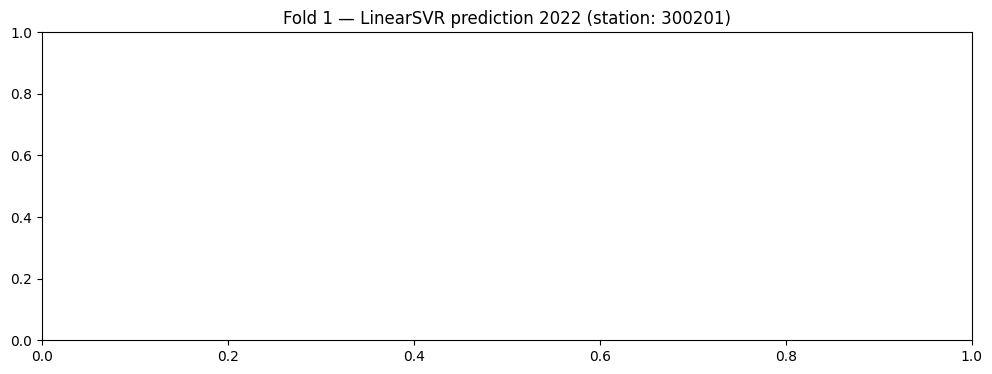

In [111]:
# ============================================================
# Plot ผลรายเดือน (เปรียบเทียบ LSTM vs LinearSVR)
# ============================================================
import matplotlib.pyplot as plt

station_idx = 0   # เลือก station ที่ต้องการดู

for fold_idx, cfg in folds.items():
    pred_year = cfg['pred_year']
    months    = pd.date_range(start=f'{pred_year}-01-01',
                              periods=HORIZON, freq='MS')

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.set_title(f"Fold {fold_idx} — LinearSVR prediction {pred_year} "
                 f"(station: {Y_full.columns[station_idx]})")

    # ── ค่าทำนาย LinearSVR ──
    # (ดึงจาก pred_df ที่คำนวณไว้ข้างบน)
    ax.plot(months,
            results_all_folds[fold_idx].get('pred_future',
                pd.DataFrame(index=months)).get(Y_full.columns[station_idx],
                [np.nan]*12),
            label='LinearSVR Pred', marker='o', linewidth=2, color='steelblue')

    # ── ค่าจริง (ถ้ามี) ──
    actual = Y_full[Y_full.index.year == pred_year]
    if len(actual) > 0:
        ax.plot(actual.index,
                actual[Y_full.columns[station_idx]],
                label='Actual', marker='s', linewidth=2,
                linestyle='--', color='tomato')

    ax.set_xlabel('Month')
    ax.set_ylabel('Rainfall (mm)')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()